<a href="https://colab.research.google.com/github/mervefilizbaker1/NLP-Homework-03-Transformer-based-Models/blob/main/nlp_hw03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Dataset**

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
!pip install transformers datasets peft accelerate evaluate scikit-learn -q

In [ ]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 7.0 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import pandas as pd
from collections import Counter
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import csv
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import get_peft_model, LoraConfig, TaskType
import evaluate
import os
import time
import csv
from tqdm import tqdm
from google.colab import userdata
from groq import Groq
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = load_dataset("dair-ai/emotion")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
print(dataset["train"][0])
print(dataset["train"][1])

{'text': 'i didnt feel humiliated', 'label': 0}
{'text': 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'label': 0}


In [ ]:
label_names = dataset["train"].features["label"].names
print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
train_labels = dataset["train"]["label"]
for label_id, count in sorted(Counter(train_labels).items()):
    print(f"  {label_names[label_id]}: {count}")

  sadness: 4666
  joy: 5362
  love: 1304
  anger: 2159
  fear: 1937
  surprise: 572


In [ ]:
train_data = dataset["train"]
val_data   = dataset["validation"]
test_data  = dataset["test"]

print(f"Train size:      {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size:       {len(test_data)}")

Train size:      16000
Validation size: 2000
Test size:       2000


In [ ]:
label_names = dataset["train"].features["label"].names

In [ ]:
test_texts  = test_data["text"]
test_labels = test_data["label"]

### Random Baseline

In [ ]:
np.random.seed(42)

In [ ]:
num_classes = len(label_names)

In [ ]:
random_preds= np.random.randint(0, num_classes, size= len(test_labels))

In [ ]:
print("Random Baseline")
print(f"Accuracy: {accuracy_score(test_labels, random_preds)}")
print(f"F1(macro): {f1_score(test_labels, random_preds, average='macro')}")

Random Baseline
Accuracy: 0.161
F1(macro): 0.14273156793118605


### Majority Class Baseline

In [ ]:
majority_class = Counter(train_data["label"]).most_common(1)[0][0]
print(f"Majority class: {label_names[majority_class]}")

Majority class: joy


In [ ]:
majority_preds = [majority_class] * len(test_labels)

In [ ]:
print("Majority Class Baseline")
print(f"Accuracy: {accuracy_score(test_labels, majority_preds)}")
print(f"F1 (macro): {f1_score(test_labels, majority_preds, average='macro', zero_division=0)}")

Majority Class Baseline
Accuracy: 0.3475
F1 (macro): 0.08596165739022882


### BOW + Logistic Regression

In [ ]:
train_texts = train_data["text"]
train_labels_list = train_data["label"]

In [ ]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, train_labels_list)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
bow_preds = lr_model.predict(X_test)

In [ ]:
print("BOW + Logistic Regression")
print(f"Accuracy:   {accuracy_score(test_labels, bow_preds)}")
print(f"F1 (macro): {f1_score(test_labels, bow_preds, average='macro')}")

BOW + Logistic Regression
Accuracy:   0.831
F1 (macro): 0.7326758043058068


In [ ]:
print(" Per-class report")
print(classification_report(test_labels, bow_preds, target_names=label_names))

 Per-class report
              precision    recall  f1-score   support

     sadness       0.87      0.91      0.89       581
         joy       0.78      0.97      0.86       695
        love       0.85      0.50      0.63       159
       anger       0.90      0.72      0.80       275
        fear       0.87      0.72      0.79       224
    surprise       0.95      0.27      0.42        66

    accuracy                           0.83      2000
   macro avg       0.87      0.68      0.73      2000
weighted avg       0.84      0.83      0.82      2000



In [ ]:
save_path = "/content/drive/MyDrive/NLP_HW03/predictions_baselines.csv"

with open(save_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["instance_id", "model_id", "prediction", "ground_truth"])

    for i, (rp, mp, bp, gt) in enumerate(zip(random_preds, majority_preds, bow_preds, test_labels)):
        writer.writerow([i, "random",   label_names[rp], label_names[gt]])
        writer.writerow([i, "majority", label_names[mp], label_names[gt]])
        writer.writerow([i, "bow_lr",   label_names[bp], label_names[gt]])

print("Saved!")

Saved!


##**2.2 Fine-tuning Pre-trained Models**

In [ ]:
BASE_PATH = "/content/drive/MyDrive/NLP_HW03"
os.makedirs(BASE_PATH, exist_ok=True)

In [ ]:
label_names = dataset["train"].features["label"].names

In [ ]:
num_labels  = len(label_names)

In [ ]:
id2label    = {i: label_names[i] for i in range(num_labels)}
label2id    = {label_names[i]: i for i in range(num_labels)}

In [ ]:
print(f"Num labels: {num_labels}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Num labels: 6
Device: cuda


In [ ]:
def get_tokenized_dataset(model_checkpoint):
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize(batch):

        return tokenizer(batch["text"], truncation=True, max_length=128)

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    return tokenizer, tokenized

In [ ]:
f1_metric  = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = acc_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

In [ ]:
def fine_tune_with_lora(model_checkpoint, model_id):
    print(f"Fine-tuning: {model_checkpoint}")

    tokenizer, tokenized_dataset = get_tokenized_dataset(model_checkpoint)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )


    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"] if "distilbert" in model_checkpoint else ["query", "value"]
    )

    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()


    output_dir = f"{BASE_PATH}/checkpoints/{model_id}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )


    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions = trainer.predict(tokenized_dataset["test"])
    preds = np.argmax(predictions.predictions, axis=-1)

    print(f"\nResults({model_id}) ---")
    print(f"Accuracy:   {predictions.metrics['test_accuracy']:.4f}")
    print(f"F1 (macro): {predictions.metrics['test_f1_macro']:.4f}")

    return preds, predictions.metrics

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
Tesla T4


In [ ]:
#DistilBert
distilbert_preds, distilbert_metrics = fine_tune_with_lora(
    "distilbert-base-uncased",
    "distilbert_lora"
)

Fine-tuning: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 742,662 || all params: 67,700,748 || trainable%: 1.0970


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.837491,0.763408,0.715000,0.569561
2,0.631941,0.592095,0.784500,0.704811
3,0.566450,0.553313,0.801500,0.732087



Results(distilbert_lora) ---
Accuracy:   0.8115
F1 (macro): 0.7308


In [ ]:
#RoBERTA
roberta_preds, roberta_metrics = fine_tune_with_lora(
    "roberta-base",
    "roberta_lora"
)

Fine-tuning: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 890,118 || all params: 125,540,364 || trainable%: 0.7090


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.799295,0.700348,0.750500,0.643413
2,0.602253,0.526581,0.808500,0.741312
3,0.543706,0.487821,0.822000,0.760949



Results(roberta_lora) ---
Accuracy:   0.8270
F1 (macro): 0.7510


In [ ]:
save_file = f"{BASE_PATH}/predictions_transformers.csv"
test_labels = dataset["test"]["label"]

with open(save_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["instance_id", "model_id", "prediction", "ground_truth"])
    for i, (dp, rp, gt) in enumerate(zip(distilbert_preds, roberta_preds, test_labels)):
        writer.writerow([i, "distilbert_lora", label_names[dp], label_names[gt]])
        writer.writerow([i, "roberta_lora",    label_names[rp], label_names[gt]])

print(f"Saved to: {save_file}")

Saved to: /content/drive/MyDrive/NLP_HW03/predictions_transformers.csv


## **2.3 Zero-shot Classification with LLMs**

In [ ]:
client = Groq(api_key=userdata.get("GROQ_API_KEY"))

In [ ]:
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello!"}],
    max_tokens=10
)

In [ ]:
print(response.choices[0].message.content)

Hello! How are you today? Is there something


In [ ]:
label_names = dataset["train"].features["label"].names

In [ ]:
def build_prompt(text):
    labels_str = ", ".join(label_names)
    return f"""You are an emotion classifier. Given a text, classify it into exactly one of these emotions: {labels_str}.

Text: "{text}"

Output ONLY the emotion label, nothing else. Do not explain, do not add punctuation."""

In [ ]:
def parse_output(raw_output):
    """
    Maps the model's raw text output to one of the valid label names.
    First tries exact match, then substring match.
    Returns "unknown" if nothing matches.
    """
    cleaned = raw_output.strip().lower()

    if cleaned in label_names:
        return cleaned

    for label in label_names:
        if label in cleaned:
            return label

    return "unknown"


In [ ]:
test_prompt = build_prompt("I am so excited about my birthday party!")
raw = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": test_prompt}],
    max_tokens=10
).choices[0].message.content

In [ ]:
print(f"Raw output : '{raw}'")
print(f"Parsed     : '{parse_output(raw)}'")

Raw output : 'joy'
Parsed     : 'joy'


In [ ]:
test_texts  = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [ ]:
groq_preds    = []
unknown_count = 0

In [ ]:
for i, text in enumerate(tqdm(test_texts, desc="Groq inference")):
    try:
        raw = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": build_prompt(text)}],
            max_tokens=10
        ).choices[0].message.content

        pred = parse_output(raw)

    except Exception as e:
        print(f"Error at example {i}: {e}")
        pred = "unknown"

    if pred == "unknown":
        unknown_count += 1
        print(f"  [unknown] raw='{raw}' | text='{text[:50]}'")

    groq_preds.append(pred)
    time.sleep(0.1)

print(f"\nDone! Unknown count: {unknown_count}/{len(test_texts)}")

Groq inference:   1%|          | 11/2000 [00:02<08:35,  3.86it/s]

  [unknown] raw='no emotion' | text='i don t feel particularly agitated'


Groq inference:   2%|▎         | 50/2000 [00:58<1:14:26,  2.29s/it]

  [unknown] raw='relief' | text='i was feeling pretty anxious all day but my first '


Groq inference:   3%|▎         | 62/2000 [01:25<1:14:58,  2.32s/it]

...

  [unknown] raw='hope/faith' | text='i really feel like they were gentle reminders that'


Groq inference: 100%|█████████▉| 1992/2000 [1:16:01<00:18,  2.31s/it]

  [unknown] raw='pity' | text='i dont blame it all to them and im not angry at th'


Groq inference: 100%|██████████| 2000/2000 [1:16:19<00:00,  2.29s/it]


Done! Unknown count: 156/2000


In [ ]:
# Ensure groq_preds has the same length as test_texts before proceeding
# (test_texts has length 2000, as shown in previous cells)
expected_length = len(test_texts)

if len(groq_preds) > expected_length:
    print(f"Warning: groq_preds has {len(groq_preds)} elements, but expected {expected_length}. Truncating.")
    groq_preds = groq_preds[:expected_length]
elif len(groq_preds) < expected_length:
    print(f"Warning: groq_preds has {len(groq_preds)} elements, but expected {expected_length}. Padding with 'unknown'.")
    groq_preds.extend(["unknown"] * (expected_length - len(groq_preds)))

valid_indices = [i for i, p in enumerate(groq_preds) if p != "unknown"]
valid_preds   = [groq_preds[i] for i in valid_indices]
valid_labels  = [label_names[test_labels[i]] for i in valid_indices]

In [ ]:
print(f"Groq (Llama 3.1 8B) Zero-shot")
print(f"Evaluated: {len(valid_preds)}/{len(test_texts)} examples")
print(f"Accuracy:   {accuracy_score(valid_labels, valid_preds)}")
print(f"F1 (macro): {f1_score(valid_labels, valid_preds, average='macro')}")

Groq (Llama 3.1 8B) Zero-shot
Evaluated: 1844/2000 examples
Accuracy:   0.5688720173535792
F1 (macro): 0.4559715042759393


In [ ]:
print("Per-class report")
print(classification_report(valid_labels, valid_preds, labels=label_names))

Per-class report
              precision    recall  f1-score   support

     sadness       0.52      0.81      0.64       557
         joy       0.76      0.59      0.66       625
        love       0.31      0.24      0.27       149
       anger       0.53      0.45      0.49       255
        fear       0.60      0.31      0.41       199
    surprise       0.26      0.27      0.27        59

    accuracy                           0.57      1844
   macro avg       0.50      0.45      0.46      1844
weighted avg       0.59      0.57      0.56      1844



In [ ]:
save_file = f"{BASE_PATH}/predictions_groq.csv"
with open(save_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["instance_id", "model_id", "prediction", "ground_truth"])
    for i, (pred, gt) in enumerate(zip(groq_preds, test_labels)):
        writer.writerow([i, "groq_llama3", pred, label_names[gt]])

print(f"\nSaved to: {save_file}")


Saved to: /content/drive/MyDrive/NLP_HW03/predictions_groq.csv


In [ ]:
# OLLAMA

In [ ]:
import os
print(os.path.exists(f"{BASE_PATH}/predictions_groq.csv"))

True


In [ ]:
OLLAMA_URL = "https://jane-unchauvinistic-harmony.ngrok-free.dev"

In [ ]:
response = requests.post(
    f"{OLLAMA_URL}/api/generate",
    json={
        "model": "gemma3:4b",
        "prompt": build_prompt("I feel so happy today!"),
        "stream": False
    },
    headers={"ngrok-skip-browser-warning": "true"},
    timeout=60
)

print(response.status_code)
print(response.json())

200
{'model': 'gemma3:4b', 'created_at': '2026-03-28T11:15:17.8882935Z', 'response': 'joy\n', 'done': True, 'done_reason': 'stop', 'context': [105, 2364, 107, 3048, 659, 614, 21543, 45211, 236761, 17770, 496, 1816, 236764, 47680, 625, 1131, 7121, 886, 529, 1239, 19979, 236787, 55882, 236764, 12690, 236764, 2765, 236764, 25046, 236764, 9891, 236764, 14089, 236761, 108, 2067, 236787, 623, 236777, 2597, 834, 5293, 3124, 9332, 108, 8433, 44917, 506, 21543, 5346, 236764, 5017, 1663, 236761, 3574, 711, 8082, 236764, 776, 711, 1138, 88078, 236761, 106, 107, 105, 4368, 107, 3672, 107], 'total_duration': 4973018100, 'load_duration': 4856231400, 'prompt_eval_count': 69, 'prompt_eval_duration': 33664800, 'eval_count': 3, 'eval_duration': 29779300}


In [ ]:
response = requests.get(
    f"{OLLAMA_URL}/api/tags",
    headers={"ngrok-skip-browser-warning": "true"}
)
print(response.status_code)
print(response.text)

200
{"models":[{"name":"gemma3:4b","model":"gemma3:4b","modified_at":"2026-03-25T22:04:11.7604556+03:00","size":3338801804,"digest":"a2af6cc3eb7fa8be8504abaf9b04e88f17a119ec3f04a3addf55f92841195f5a","details":{"parent_model":"","format":"gguf","family":"gemma3","families":["gemma3"],"parameter_size":"4.3B","quantization_level":"Q4_K_M"}}]}


In [ ]:
test_texts  = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [ ]:
ollama_preds  = []
unknown_count = 0

In [ ]:
for i, text in enumerate(tqdm(test_texts, desc="Ollama inference")):
    try:
        response = requests.post(
            f"{OLLAMA_URL}/api/generate",
            json={
                "model": "gemma3:4b",
                "prompt": build_prompt(text),
                "stream": False
            },
            headers={"ngrok-skip-browser-warning": "true"},
            timeout=60
        )
        raw  = response.json()["response"]
        pred = parse_output(raw)

    except Exception as e:
        print(f"Error at example {i}: {e}")
        pred = "unknown"

    if pred == "unknown":
        unknown_count += 1
        print(f"  [unknown] raw='{raw}' | text='{text[:50]}'")

    ollama_preds.append(pred)

print(f"\nDone! Unknown count: {unknown_count}/{len(test_texts)}")

Ollama inference:   1%|          | 11/2000 [00:07<21:35,  1.53it/s]

  [unknown] raw='neutral
' | text='i don t feel particularly agitated'


Ollama inference:   4%|▎         | 73/2000 [00:49<20:36,  1.56it/s]

  [unknown] raw='confusion
' | text='i am right handed however i play billiards left ha'


Ollama inference:   4%|▍         | 89/2000 [01:00<20:28,  1.56it/s]

...

  [unknown] raw='neutral' | text='i have no strong feelings for this book neither ha'


Ollama inference: 100%|█████████▉| 1992/2000 [25:34<00:04,  1.69it/s]

  [unknown] raw='sympathy
' | text='i dont blame it all to them and im not angry at th'


Ollama inference: 100%|██████████| 2000/2000 [25:39<00:00,  1.30it/s]


Done! Unknown count: 25/2000


In [ ]:
valid_indices = [i for i, p in enumerate(ollama_preds) if p != "unknown"]
valid_preds   = [ollama_preds[i] for i in valid_indices]
valid_labels  = [label_names[test_labels[i]] for i in valid_indices]

In [ ]:
print(f"Ollama (Gemma 3 4B) Zero-shot")
print(f"Evaluated: {len(valid_preds)}/{len(test_texts)} examples")
print(f"Accuracy:   {accuracy_score(valid_labels, valid_preds)}")
print(f"F1 (macro): {f1_score(valid_labels, valid_preds, average='macro')}")

Ollama (Gemma 3 4B) Zero-shot
Evaluated: 1975/2000 examples
Accuracy:   0.5620253164556962
F1 (macro): 0.47303650503244093


In [ ]:
print("Per-class report")
print(classification_report(valid_labels, valid_preds, labels=label_names))

Per-class report
              precision    recall  f1-score   support

     sadness       0.52      0.79      0.63       578
         joy       0.76      0.54      0.63       686
        love       0.34      0.27      0.30       157
       anger       0.53      0.50      0.52       270
        fear       0.52      0.36      0.43       221
    surprise       0.33      0.33      0.33        63

    accuracy                           0.56      1975
   macro avg       0.50      0.47      0.47      1975
weighted avg       0.58      0.56      0.56      1975



In [ ]:
OLLAMA_URL = "https://jane-unchauvinistic-harmony.ngrok-free.dev"

def query_ollama(text):
    response = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={
            "model": "gemma3:4b",
            "prompt": build_prompt(text),
            "stream": False
        },
        headers={"ngrok-skip-browser-warning": "true"},
        timeout=60
    )
    return response.json()["response"]

In [ ]:
raw = query_ollama("I feel so happy today!")
print(f"Raw output: '{raw}'")

Raw output: 'joy
'


In [ ]:
print(build_prompt("test"))
print(parse_output("joy"))
print(query_ollama("I feel happy"))

You are an emotion classifier. Given a text, classify it into exactly one of these emotions: sadness, joy, love, anger, fear, surprise.

Text: "test"

Output ONLY the emotion label, nothing else. Do not explain, do not add punctuation.
joy
joy



In [ ]:
print(len(ollama_preds))
print(ollama_preds[:5])

2000
['sadness', 'sadness', 'love', 'joy', 'sadness']


In [ ]:
save_file = f"{BASE_PATH}/predictions_ollama.csv"
with open(save_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["instance_id", "model_id", "prediction", "ground_truth"])
    for i, (pred, gt) in enumerate(zip(ollama_preds, test_labels)):
        writer.writerow([i, "ollama_gemma3", pred, label_names[gt]])

print(f"Saved to: {save_file}")

Saved to: /content/drive/MyDrive/NLP_HW03/predictions_ollama.csv


In [ ]:
valid_indices = [i for i, p in enumerate(ollama_preds) if p != "unknown"]
valid_preds   = [ollama_preds[i] for i in valid_indices]
valid_labels  = [label_names[test_labels[i]] for i in valid_indices]

In [ ]:
print(f"Ollama (Gemma 3 4B) Zero-shot")
print(f"Evaluated: {len(valid_preds)}/{len(test_texts)} examples")
print(f"Accuracy:   {accuracy_score(valid_labels, valid_preds)}")
print(f"F1 (macro): {f1_score(valid_labels, valid_preds, average='macro')}")

Ollama (Gemma 3 4B) Zero-shot
Evaluated: 1975/2000 examples
Accuracy:   0.5620253164556962
F1 (macro): 0.47303650503244093


In [ ]:
print("Per-class report")
print(classification_report(valid_labels, valid_preds, labels=label_names))

Per-class report
              precision    recall  f1-score   support

     sadness       0.52      0.79      0.63       578
         joy       0.76      0.54      0.63       686
        love       0.34      0.27      0.30       157
       anger       0.53      0.50      0.52       270
        fear       0.52      0.36      0.43       221
    surprise       0.33      0.33      0.33        63

    accuracy                           0.56      1975
   macro avg       0.50      0.47      0.47      1975
weighted avg       0.58      0.56      0.56      1975



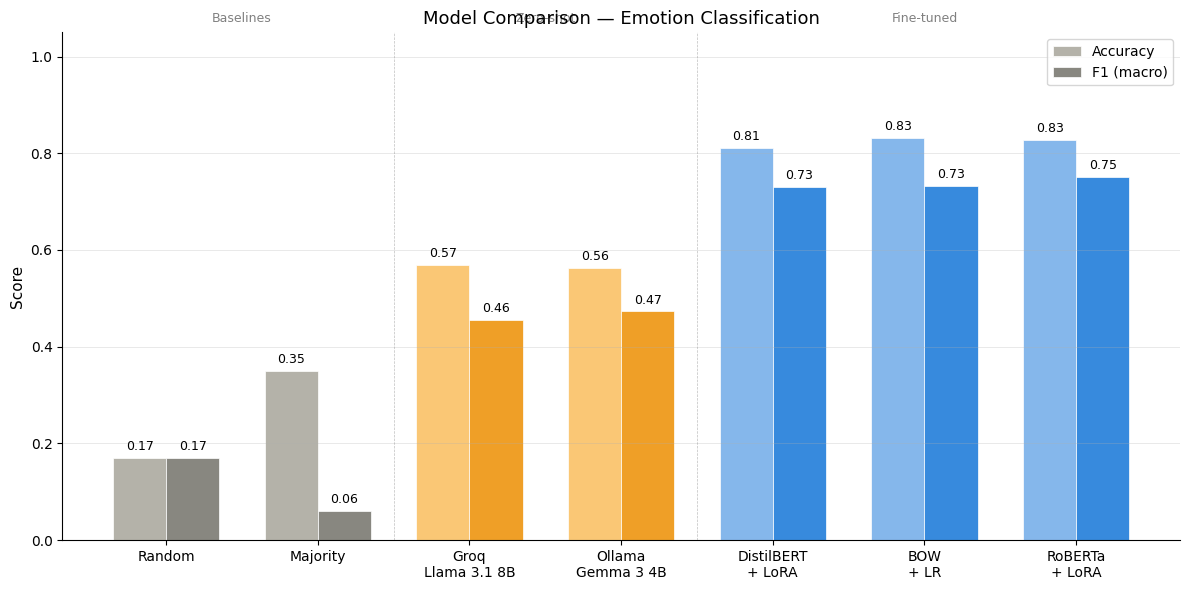

Saved!


In [ ]:
models = [
    "Random",
    "Majority",
    "Groq\nLlama 3.1 8B",
    "Ollama\nGemma 3 4B",
    "DistilBERT\n+ LoRA",
    "BOW\n+ LR",
    "RoBERTa\n+ LoRA",
]

accuracy = [0.17, 0.35, 0.5689, 0.5620, 0.8110, 0.8310, 0.8270]
f1_macro = [0.17, 0.06, 0.4560, 0.4730, 0.7302, 0.7327, 0.7510]

colors_acc = ["#B4B2A9", "#B4B2A9", "#FAC775", "#FAC775", "#85B7EB", "#85B7EB", "#85B7EB"]
colors_f1  = ["#888780", "#888780", "#EF9F27", "#EF9F27", "#378ADD", "#378ADD", "#378ADD"]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, accuracy, width, label="Accuracy", color=colors_acc, edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x + width/2, f1_macro,  width, label="F1 (macro)", color=colors_f1,  edgecolor="white", linewidth=0.5)


for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Emotion Classification", fontsize=13, fontweight="normal")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.4)


ax.axvline(x=1.5, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(x=3.5, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
ax.text(0.5,  1.02, "Baselines",   ha="center", fontsize=9, color="gray", transform=ax.get_xaxis_transform())
ax.text(2.5,  1.02, "Zero-shot",   ha="center", fontsize=9, color="gray", transform=ax.get_xaxis_transform())
ax.text(5,    1.02, "Fine-tuned",  ha="center", fontsize=9, color="gray", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## **2.4 Baselines**

In [ ]:
train_labels = dataset["train"]["label"]
test_labels  = dataset["test"]["label"]
label_names  = dataset["train"].features["label"].names
num_classes  = len(label_names)

In [ ]:
counts = Counter(train_labels)
total  = len(train_labels)

In [ ]:
print("Class Distribution (Train)")
for label_id, count in sorted(counts.items()):
    print(f"  {label_names[label_id]}: {count} ({count/total:.2%})")

Class Distribution (Train)
  sadness: 4666 (29.16%)
  joy: 5362 (33.51%)
  love: 1304 (8.15%)
  anger: 2159 (13.49%)
  fear: 1937 (12.11%)
  surprise: 572 (3.57%)


In [ ]:
probs = [counts[i] / total for i in range(num_classes)]
random_acc = sum(p**2 for p in probs)

In [ ]:
print(f" Random Baseline (theoretical)")
print(f"Accuracy: {random_acc:.4f}")
print(f"F1 (macro, uniform guess): {1/num_classes:.4f}")

 Random Baseline (theoretical)
Accuracy: 0.2381
F1 (macro, uniform guess): 0.1667


In [ ]:
majority_class = counts.most_common(1)[0][0]
majority_count = counts.most_common(1)[0][1]
majority_acc   = majority_count / len(test_labels)

In [ ]:
print(f"Majority Baseline (theoretical)")
print(f"Majority class: {label_names[majority_class]}")
print(f"Accuracy: {majority_acc:.4f}")

Majority Baseline (theoretical)
Majority class: joy
Accuracy: 2.6810
